# **Task 1**

In [4]:
import pandas as pd
# Load directly from URL (no download needed)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print('Dataset loaded! Shape:', df.shape)

Dataset loaded! Shape: (891, 12)


In [5]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
# Load the Titanic dataset
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url) # pd.read_csv reads any CSV file into a DataFrame
print('Data loaded successfully!')
print('Rows:', df.shape[0], '| Columns:', df.shape[1])


Data loaded successfully!
Rows: 891 | Columns: 12


In [6]:
# See the first 5 rows
print(df.head())
# See column names and data types
print(df.dtypes)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,1.904602,0.602694
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,1.000000


In [29]:
# Count missing values in each column
print(df.isnull().sum())



PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
AgeGroup       0
dtype: int64


In [30]:
# Show as percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct.round(2))

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
FamilySize     0.0
IsAlone        0.0
AgeGroup       0.0
dtype: float64


In [8]:
# Strategy A: Fill missing Age with the MEDIAN age
# (Median is better than mean when there are outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)
# Strategy B: Fill missing Embarked with the most common value (mode)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
# Strategy C: Drop the Cabin column (too many missing values)
df.drop(columns=['Cabin'], inplace=True)
# Verify - should now show

/tmp/ipykernel_644/1554372992.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_644/1554372992.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [9]:
# Check for duplicate rows
print('Duplicates before:', df.duplicated().sum())
# Remove duplicates
df.drop_duplicates(inplace=True)
print('Duplicates after:', df.duplicated().sum())
print('Final dataset shape:', df.shape)


Duplicates before: 0
Duplicates after: 0
Final dataset shape: (891, 11)


In [10]:
# Q1: How many passengers survived?
print('Survived:', df['Survived'].value_counts())
print('Survival Rate:', df['Survived'].mean() * 100, '%')
# Q2: What was the average age by passenger class?
print(df.groupby('Pclass')['Age'].mean().round(1))
# Q3: Did women survive more than men?
print(df.groupby('Sex')['Survived'].mean() * 100)
# Q4: Correlation between Fare paid and survival?
print(df[['Fare','Survived','Age']].corr().round(2))


Survived: Survived
0    549
1    342
Name: count, dtype: int64
Survival Rate: 38.38383838383838 %
Pclass
1    36.8
2    29.8
3    25.9
Name: Age, dtype: float64
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
          Fare  Survived   Age
Fare      1.00      0.26  0.10
Survived  0.26      1.00 -0.06
Age       0.10     -0.06  1.00


In [11]:
# Create a 'FamilySize' column (siblings + parents + self)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# Create 'IsAlone' column - 1 if travelling alone, 0 otherwise
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
# Create Age groups
df['AgeGroup'] = pd.cut(df['Age'],
bins=[0, 12, 18, 35, 60, 100],
labels=['Child','Teen','Young Adult','Adult','Senior'])
print(df[['Age','AgeGroup','FamilySize','IsAlone']].head(8))


    Age     AgeGroup  FamilySize  IsAlone
0  22.0  Young Adult           2        0
1  38.0        Adult           2        0
2  26.0  Young Adult           1        1
3  35.0  Young Adult           2        0
4  35.0  Young Adult           1        1
5  28.0  Young Adult           1        1
6  54.0        Adult           1        1
7   2.0        Child           5        0


In [12]:
# Save cleaned dataset to a new CSV file
df.to_csv('titanic_cleaned.csv', index=False)
print('Cleaned dataset saved! Rows:', len(df))
# Verify it saved correctly
df_check = pd.read_csv('titanic_cleaned.csv')
print('Loaded back successfully:', df_check.shape)

Cleaned dataset saved! Rows: 891
Loaded back successfully: (891, 14)


# **Task 2**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Set Seaborn style for all plots (makes them look professional)
sns.set_theme(style='whitegrid', palette='muted')
# Load cleaned data from Task 1
df = pd.read_csv('titanic_cleaned.csv')
print('Data loaded. Shape:', df.shape)

Data loaded. Shape: (891, 14)


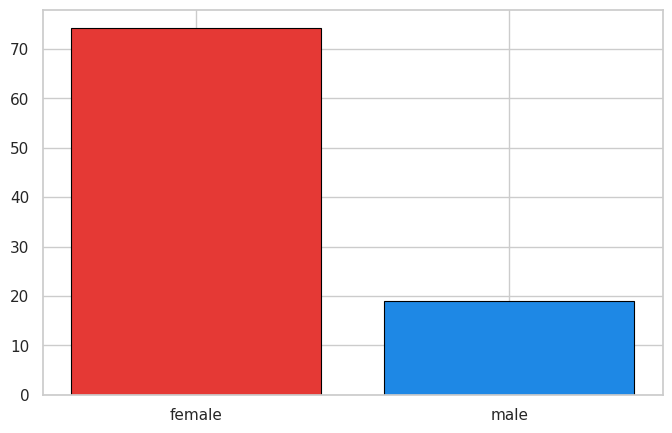

In [14]:
fig, ax = plt.subplots(figsize=(8, 5)) # Create a figure (8 inches wide, 5 tall)
# Count survivors by sex and plot
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
colors_list = ['#E53935', '#1E88E5'] # Red for female, Blue for male
bars = ax.bar(survival_by_sex.index, survival_by_sex.values,
color=colors_list, edgecolor='black', linewidth=0.8)

In [19]:
# Add value labels ON TOP of each bar
for bar, val in zip(bars, survival_by_sex.values):
 ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
  f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Survival Rate by Gender – Titanic', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 90)
plt.tight_layout()
plt.savefig('chart1_survival_by_gender.png', dpi=150)
plt.show()
print('Chart 1 saved!')


<Figure size 640x480 with 0 Axes>

Chart 1 saved!


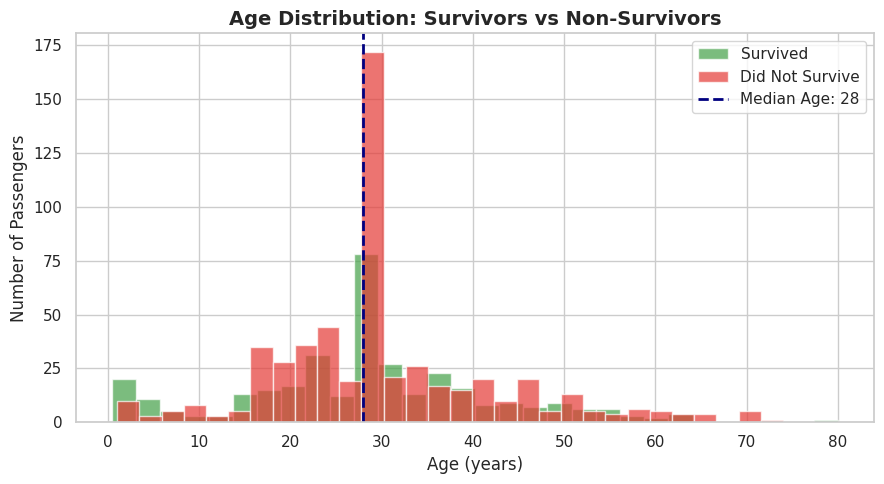

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
# Plot separate histograms for survivors vs non-survivors
df[df['Survived']==1]['Age'].hist(bins=30, alpha=0.7, label='Survived',
color='#43A047', ax=ax)
df[df['Survived']==0]['Age'].hist(bins=30, alpha=0.7, label='Did Not Survive',
color='#E53935', ax=ax)
ax.set_title('Age Distribution: Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.legend(fontsize=11)
# Add a vertical line at median age
median_age = df['Age'].median()
ax.axvline(median_age, color='navy', linestyle='--', linewidth=2,
label=f'Median Age: {median_age:.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_age_distribution.png', dpi=150)
plt.show()


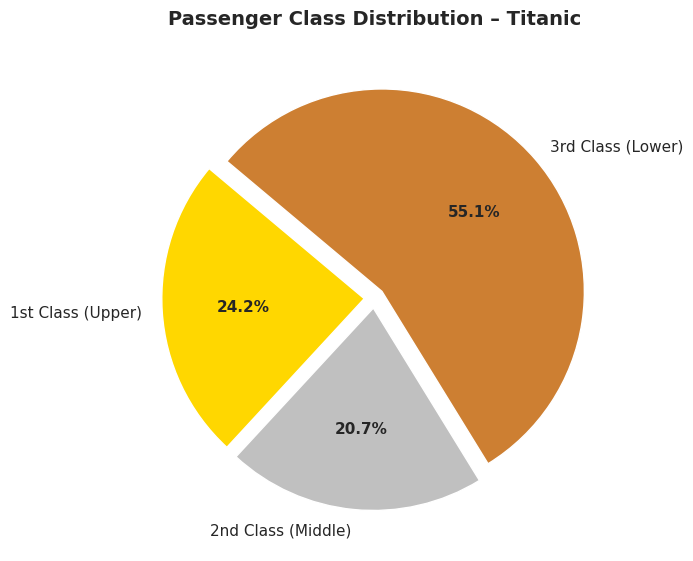

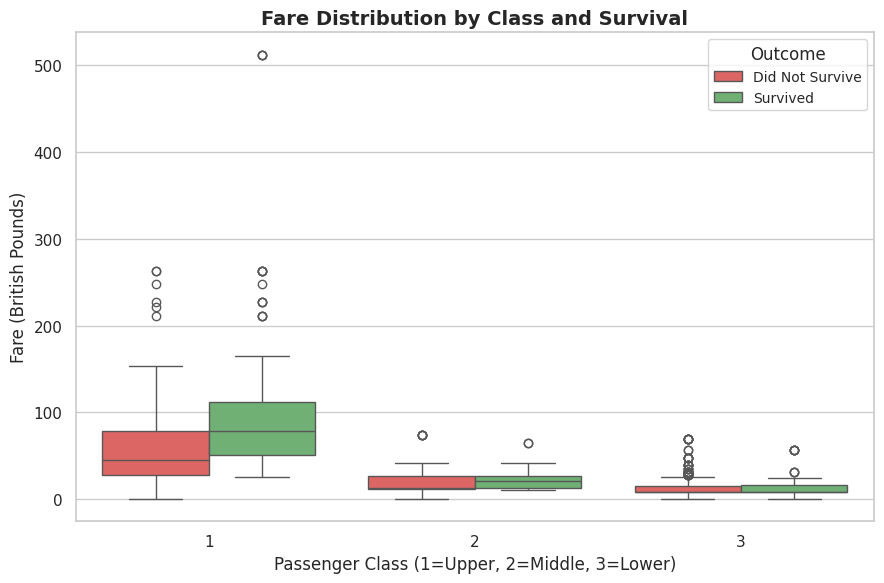

In [24]:
fig, ax = plt.subplots(figsize=(7, 7))
class_counts = df['Pclass'].value_counts().sort_index()
labels = ['1st Class (Upper)', '2nd Class (Middle)', '3rd Class (Lower)']
colors_pie = ['#FFD700', '#C0C0C0', '#CD7F32'] # Gold, Silver, Bronze
explode = (0.05, 0.05, 0.05) # Slightly separate all slices
wedges, texts, autotexts = ax.pie(
class_counts.values, labels=labels, colors=colors_pie,
autopct='%1.1f%%', explode=explode, startangle=140,
textprops={'fontsize': 11})
# Make percentage text bold
for autotext in autotexts:
 autotext.set_fontweight('bold')
ax.set_title('Passenger Class Distribution – Titanic', fontsize=14, fontweight='bold', padfig, ax = plt.subplots(figsize=(9, 6))
# Seaborn boxplot - notice how SHORT the code is compared to Matplotlib!
sns.boxplot(data=df, x='Pclass', y='Fare', hue='Survived',palette={0: '#EF5350', 1: '#66BB6A'}, ax=ax)
ax.set_title('Fare Distribution by Class and Survival', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class (1=Upper, 2=Middle, 3=Lower)', fontsize=12)
ax.set_ylabel('Fare (British Pounds)', fontsize=12)
# Rename legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Did Not Survive', 'Survived'], title='Outcome', fontsize=10)
plt.tight_layout()
plt.savefig('chart4_fare_boxplot.png', dpi=150)
plt.show()

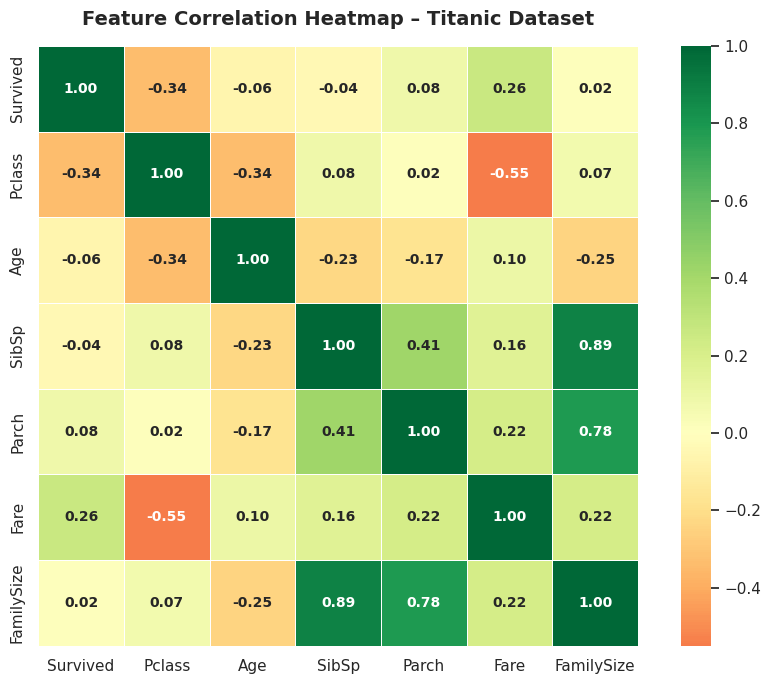

Highest correlation with Survival:
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64


In [25]:
fig, ax = plt.subplots(figsize=(9, 7))
# Select only numeric columns
numeric_cols = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']]
# Compute correlation matrix
corr = numeric_cols.corr()
# Draw heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
center=0, linewidths=0.5, square=True,
annot_kws={'size': 10, 'weight': 'bold'}, ax=ax)
ax.set_title('Feature Correlation Heatmap – Titanic Dataset',
fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150)
plt.show()
# Interpret top correlations
print('Highest correlation with Survival:')
print(corr['Survived'].sort_values(ascending=False))

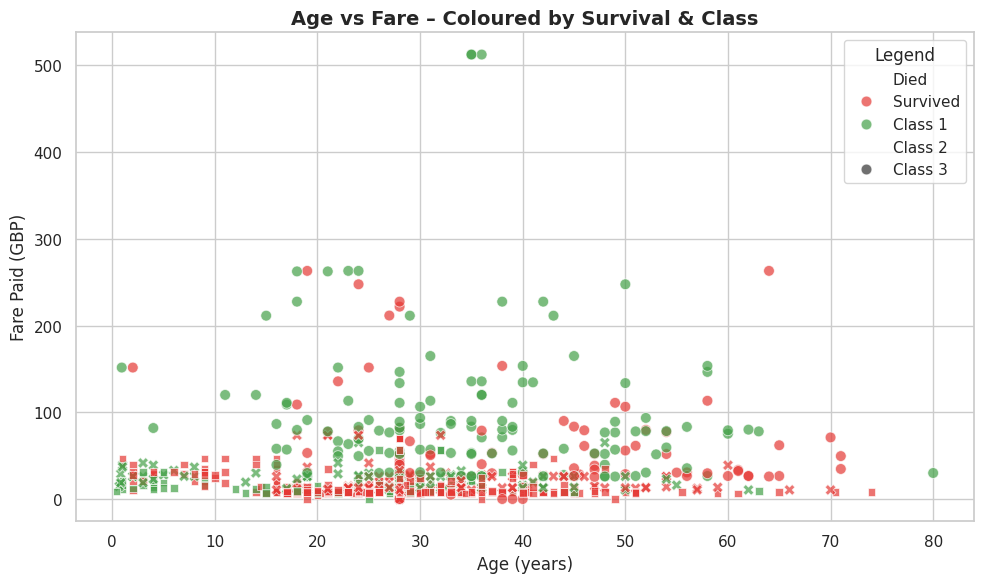

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
# Color dots by survival outcome
sns.scatterplot(data=df, x='Age', y='Fare',
hue='Survived', style='Pclass',
palette={0:'#E53935', 1:'#43A047'},
alpha=0.7, s=60, ax=ax)
ax.set_title('Age vs Fare – Coloured by Survival & Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare Paid (GBP)', fontsize=12)
# Update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Died','Survived','Class 1','Class 2','Class 3'],
title='Legend', loc='upper right')
plt.tight_layout()
plt.savefig('chart6_age_vs_fare_scatter.png', dpi=150)
plt.show()

/tmp/ipykernel_644/4102718170.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[1,1],


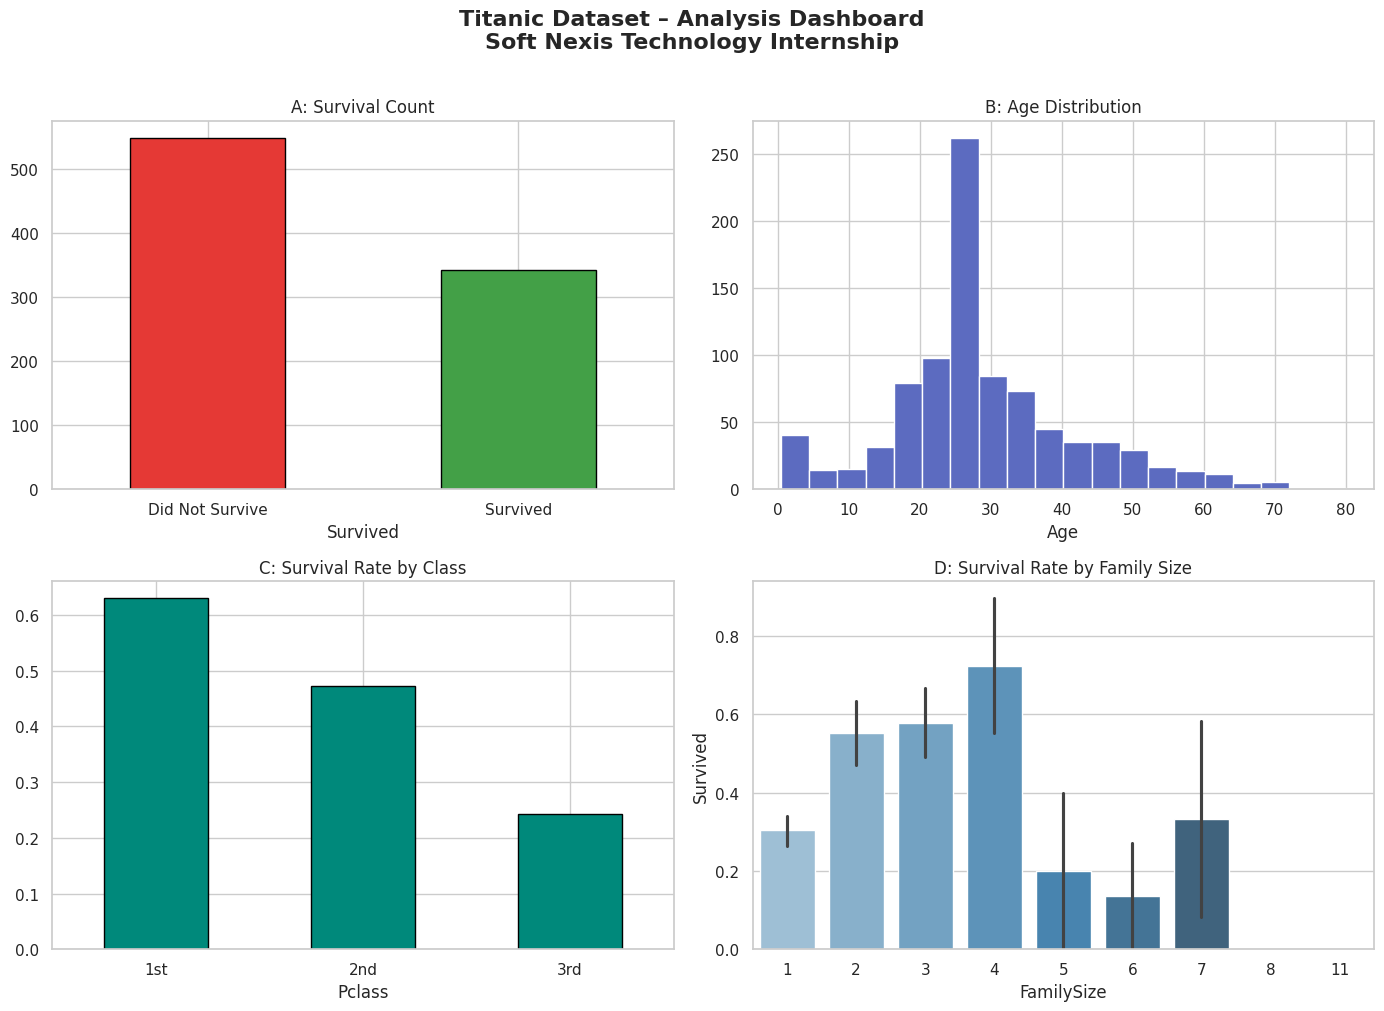

Dashboard saved!


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # 2 rows x 2 columns
fig.suptitle('Titanic Dataset – Analysis Dashboard\nSoft Nexis Technology Internship',
fontsize=16, fontweight='bold', y=1.01)
# Chart A: Survival count
df['Survived'].value_counts().plot(kind='bar', ax=axes[0,0],
color=['#E53935','#43A047'], edgecolor='black')
axes[0,0].set_title('A: Survival Count')
axes[0,0].set_xticklabels(['Did Not Survive','Survived'], rotation=0)
# Chart B: Age distribution
df['Age'].hist(bins=20, ax=axes[0,1], color='#5C6BC0', edgecolor='white')
axes[0,1].set_title('B: Age Distribution')
axes[0,1].set_xlabel('Age')
# Chart C: Survival by class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1,0],
color='#00897B', edgecolor='black')
axes[1,0].set_title('C: Survival Rate by Class')
axes[1,0].set_xticklabels(['1st','2nd','3rd'], rotation=0)
# Chart D: Family size vs survival
sns.barplot(data=df, x='FamilySize', y='Survived', ax=axes[1,1],
palette='Blues_d')
axes[1,1].set_title('D: Survival Rate by Family Size')
plt.tight_layout()
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved!')


In [ ]:
### Key Findings from EDA

1. Survival by Gender: There is a stark contrast in survival rates; 74.2% of females survived compared to only 18.9% of males,
   confirming the 'women and children first' protocol.

2. Class and Fare Correlation: Pclass has a strong negative correlation (-0.34) with survival, meaning higher-class passengers (Class 1)
   were much more likely to survive than lower-class passengers (Class 3). This is also reflected in the `Fare` distribution.

3. Demographics: The Age distribution shows that young children had a higher survival frequency relative to their group size,
   while the median age of the overall passenger list was 28 years old.